# Enerji Tüketimi Modellemesi: Doğrusal Regresyon ve Yapay Sinir Ağları (MLP)

In [ ]:
!pip install -q gdown
import gdown
gdown.download('https://drive.google.com/uc?id=13R-wF-on6wqzGFe4DXUJ-VTR12P259NQ', 'enerji_tuketimi.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=13R-wF-on6wqzGFe4DXUJ-VTR12P259NQ
To: /content/enerji_tuketimi.csv
100%|██████████| 1.02k/1.02k [00:00<00:00, 3.54MB/s]


'enerji_tuketimi.csv'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
veri_dosyasi = 'enerji_tuketimi.csv'
df = pd.read_csv(veri_dosyasi)

In [ ]:
X = df[['sicaklik']]
y = df['enerji']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
mlp_model = MLPRegressor(hidden_layer_sizes=(10,), max_iter = 1000, random_state = 42)
mlp_model.fit(X_train_scaled, y_train_scaled)

MLPRegressor(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)

In [ ]:
lr_pred = lr_model.predict(X_test)
mlp_pred_scaled = mlp_model.predict(X_test_scaled)
mlp_pred = scaler_y.inverse_transform(mlp_pred_scaled.reshape(-1, 1)).ravel()

In [ ]:
print("       Model       |   MSE   |  R^2")
print("-" * 40)
print(f"Doğrusal Regresyon | {mean_squared_error(y_test, lr_pred):.2f} | {r2_score(y_test, lr_pred):.3f}")
print(f"Yapay Sinir Ağı    | {mean_squared_error(y_test, mlp_pred):.2f}  | {r2_score(y_test, mlp_pred):.3f}")

       Model       |   MSE   |  R^2
----------------------------------------
Doğrusal Regresyon | 1171.40 | 0.675
Yapay Sinir Ağı    | 206.05  | 0.943


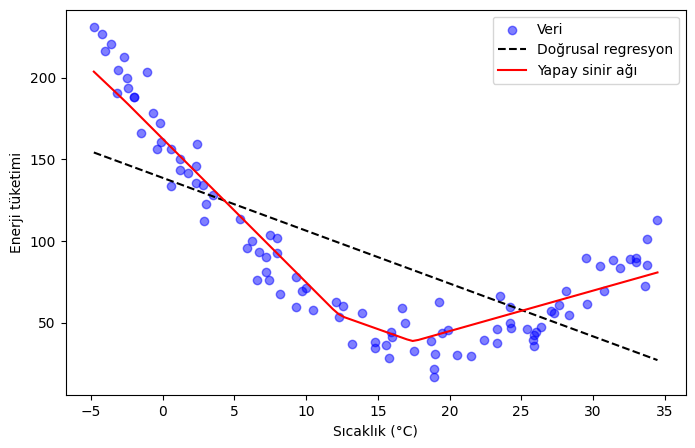

In [ ]:
X_plot_vals = np.linspace(X.min().values[0], X.max().values[0], 100).reshape(-1, 1)
X_plot = pd.DataFrame(X_plot_vals, columns=['sicaklik'])
lr_plot = lr_model.predict(X_plot)
mlp_plot = scaler_y.inverse_transform(mlp_model.predict(scaler_X.transform(X_plot)).reshape(-1, 1)).ravel()

plt.figure(figsize=(8,5))
plt.scatter(X, y, color='blue', alpha=0.5, label='Veri')
plt.plot(X_plot, lr_plot, 'k--', label='Doğrusal regresyon')
plt.plot(X_plot, mlp_plot, 'r-', label='Yapay sinir ağı')
plt.xlabel('Sıcaklık (°C)')
plt.ylabel('Enerji tüketimi')
plt.legend()
plt.show()